# NLP Emotion Counseling Conversations Training Phase
## Using DistilBERT base uncased (Finetuned on Dair/AI dataset, The split version [20k rows])

In [1]:
!pip install -U transformers
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.9 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [2]:
from datasets import Dataset
from transformers import DataCollatorWithPadding
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import login
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import pipeline
from transformers import EarlyStoppingCallback
import torch

In [3]:
import os

# Create output directories
os.makedirs("/kaggle/working/assets", exist_ok=True)
os.makedirs("/kaggle/working/assets/figures", exist_ok=True)
os.makedirs("/kaggle/working/assets/metrics", exist_ok=True)

Define the Labels used for the DAIR Dataset

In [4]:
LabelMap = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}
label2id = {v: k for k, v in LabelMap.items()}

Loading the Model itself and specify its tokenizer

In [5]:
login()

In [6]:
# Load model directly

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# got rid of this model since it was already finetuned on DAIR AI
# tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
# model = AutoModelForSequenceClassification.from_pretrained(
#     "bhadresh-savani/distilbert-base-uncased-emotion",
#     num_labels=6,
#     ignore_mismatched_sizes=True,
#     id2label=LabelMap,
#     label2id=label2id,
#     )

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6,
    ignore_mismatched_sizes=True,
    id2label=LabelMap,
    label2id=label2id,
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# I will be using the split version of DAIR AI (The default) since it has ~ 20K rows. On the other hand, the unsplit version has 420k rows which is an overkill for finetuning

In [7]:
ds = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [9]:
dsdf_train = ds['train'].to_pandas()
dsdf_test = ds['test'].to_pandas()
dsdf_val = ds['validation'].to_pandas()

In [10]:
dsdf_train

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [11]:
dsdf_train.duplicated().sum()

np.int64(1)

In [12]:
dsdf_train.drop_duplicates(inplace=True)

In [13]:
dsdf_train.isna().sum()

text     0
label    0
dtype: int64

In [14]:
dsdf_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15999 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    15999 non-null  object
 1   label   15999 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 375.0+ KB


Important Visualization about the Data

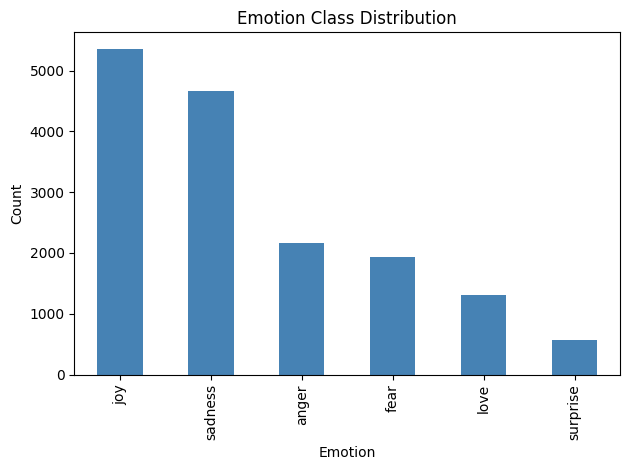

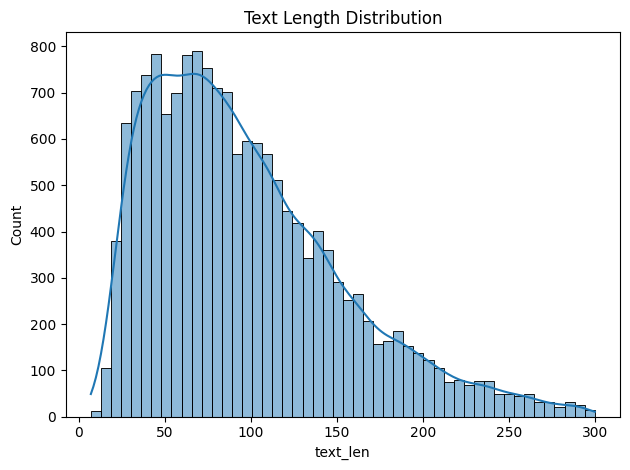

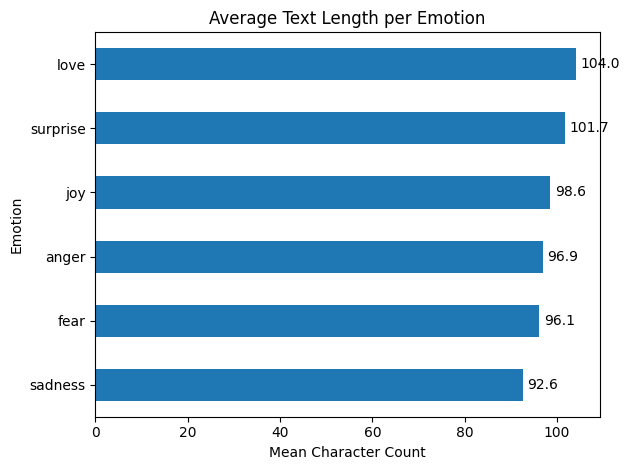

In [15]:
# check for imbalance
eda_df = dsdf_train.copy()
eda_df['emotion'] = eda_df['label'].map(LabelMap)
eda_df['text_len'] = eda_df['text'].apply(len)

# check for imbalance
eda_df['emotion'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("/kaggle/working/assets/figures/class_distribution.png", dpi=150)
plt.show()

sns.histplot(eda_df['text_len'], bins=50, kde=True)
plt.title('Text Length Distribution')
plt.tight_layout()
plt.savefig("/kaggle/working/assets/figures/text_length_distribution.png", dpi=150)
plt.show()

ax = eda_df.groupby('emotion')['text_len'].mean().sort_values().plot(kind='barh')
plt.title('Average Text Length per Emotion')
plt.xlabel('Mean Character Count')
plt.ylabel('Emotion')
for bar in ax.patches:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.1f}', va='center')
plt.tight_layout()
plt.savefig("/kaggle/working/assets/figures/avg_text_length_per_emotion.png", dpi=150)
plt.show()

In [16]:
def tokenize_function(examples):
    # This automatically formats the data into input_ids and attention_mask
    return tokenizer(examples["text"], truncation=True)

In [17]:
# Convert pandas DataFrame back to Hugging Face Dataset
final_ds = Dataset.from_pandas(dsdf_train, preserve_index=False)
final_ds_test = Dataset.from_pandas(dsdf_test, preserve_index=False)
final_ds_val = Dataset.from_pandas(dsdf_val, preserve_index=False)

In [18]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Apply formatting across the dataset using batched=True
tokenized_datasets = final_ds.map(tokenize_function, batched=True)
# Set the format to PyTorch tensors
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_val  = final_ds_val.map(tokenize_function, batched=True)
tokenized_test = final_ds_test.map(tokenize_function, batched=True)

tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(tokenized_datasets)

Map:   0%|          | 0/15999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15999
})


### Prepare Training and Validation Splits
We'll split the tokenized dataset into a training set and a test set to monitor performance during training.

In [19]:
train_dataset = tokenized_datasets
eval_dataset  = tokenized_val
test_dataset  = tokenized_test


print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 15999
Validation samples: 2000
Testing samples: 2000


### Define Training Arguments and Initialize Trainer
We will configure the `TrainingArguments` and use the `Trainer` class. Note: This model is quite large, so we use a small batch size to fit in Colab's GPU memory.

In [20]:
accuracy_metric  = evaluate.load("accuracy")
f1_metric        = evaluate.load("f1")
recall_metric    = evaluate.load("recall")
precision_metric = evaluate.load("precision")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        **accuracy_metric.compute(predictions=predictions, references=labels),
        **f1_metric.compute(predictions=predictions, references=labels, average="weighted"),
        **recall_metric.compute(predictions=predictions, references=labels, average="weighted"),
        **precision_metric.compute(predictions=predictions, references=labels, average="weighted"),
        "f1_macro":        f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"],
        "recall_macro":    recall_metric.compute(predictions=predictions, references=labels, average="macro")["recall"],
        "precision_macro": precision_metric.compute(predictions=predictions, references=labels, average="macro")["precision"],

    }

### to handle class imbalance we would penalizes the model more for misclassifying minority classes

In [21]:
from sklearn.utils.class_weight import compute_class_weight
device = torch.device('cuda')

classes = np.unique(dsdf_train['label'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=dsdf_train['label'])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

class PenalizeTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        if return_outputs:
            return loss, outputs
        return loss

In [22]:
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="Distilbert-Emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=15,
    weight_decay=0.01,
    load_best_model_at_end=True,
    save_total_limit=1,
    metric_for_best_model="accuracy",
    logging_steps=100,
    push_to_hub=False,
    fp16=True,
    report_to="none"
)

trainer = PenalizeTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
# Start training
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall,Precision,F1 Macro,Recall Macro,Precision Macro
1,1.547255,0.777270,0.779000,0.786313,0.779000,0.811109,0.751364,0.799196,0.727844
2,0.256884,0.204449,0.927000,0.928749,0.927000,0.935127,0.902997,0.938039,0.879124
3,0.189357,0.163256,0.929500,0.930954,0.929500,0.937507,0.906841,0.942083,0.882360
4,0.145338,0.154663,0.933500,0.934893,0.933500,0.941116,0.909751,0.941056,0.887859
5,0.115960,0.171827,0.934000,0.935258,0.934000,0.939767,0.911160,0.940201,0.890023
6,0.092498,0.186932,0.935500,0.936248,0.935500,0.938316,0.909699,0.925387,0.896807
7,0.068183,0.222170,0.936500,0.937365,0.936500,0.939983,0.914256,0.931640,0.900367
8,0.065726,0.252734,0.933000,0.933542,0.933000,0.935233,0.907501,0.919071,0.898675
9,0.048378,0.315353,0.938000,0.938357,0.938000,0.939514,0.914297,0.919290,0.910444
10,0.031821,0.328778,0.932500,0.932873,0.932500,0.933507,0.908001,0.915505,0.901072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2750, training_loss=0.24521203400871971, metrics={'train_runtime': 608.9133, 'train_samples_per_second': 394.12, 'train_steps_per_second': 6.159, 'total_flos': 2576174544239148.0, 'train_loss': 0.24521203400871971, 'epoch': 11.0})

In [23]:
import shutil
shutil.rmtree("/kaggle/working/Distilbert-Emotion", ignore_errors=True)

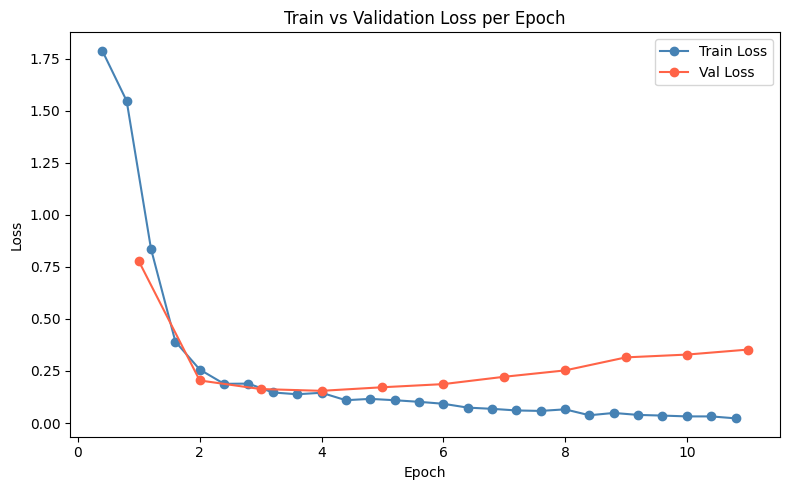

In [24]:

log_df = pd.DataFrame(trainer.state.log_history)

train_loss = log_df[log_df['loss'].notna()][['epoch', 'loss']]
train_loss_per_epoch = train_loss.groupby('epoch')['loss'].mean().reset_index()

eval_df = log_df[log_df['eval_loss'].notna()][['epoch', 'eval_loss']]

plt.figure(figsize=(8, 5))
plt.plot(train_loss_per_epoch['epoch'], train_loss_per_epoch['loss'], marker='o', label='Train Loss', color='steelblue')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], marker='o', label='Val Loss', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss per Epoch')
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/assets/figures/loss_curve.png", dpi=150)
plt.show()

In [25]:
 # Evaluate the model on the validation split
eval_results = trainer.evaluate()
print(f"Final Validation Results: {eval_results}")

Training Loss,Validation Loss,Epoch,Accuracy,F1,Recall,Precision,F1 Macro,Recall Macro,Precision Macro
0.022497,0.315353,11,0.938000,0.938357,0.938000,0.939514,0.914297,0.919290,0.910444


Final Validation Results: {'eval_loss': 0.3153529763221741, 'eval_accuracy': 0.938, 'eval_f1': 0.9383570304206297, 'eval_recall': 0.938, 'eval_precision': 0.9395135484003188, 'eval_f1_macro': 0.9142972738564579, 'eval_recall_macro': 0.9192897672250502, 'eval_precision_macro': 0.9104435360404607}


In [26]:
# Save the model and tokenizer to a local folder
model.save_pretrained("./final_mental_emotion_model")
tokenizer.save_pretrained("./final_mental_emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_mental_emotion_model/tokenizer_config.json',
 './final_mental_emotion_model/tokenizer.json')

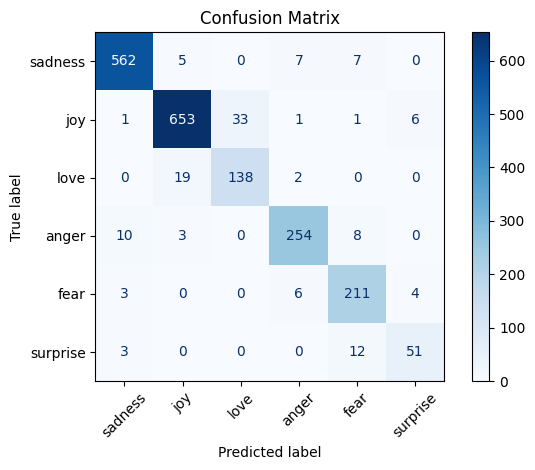

In [27]:
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(LabelMap.values()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("/kaggle/working/assets/figures/confusion_matrix.png", dpi=150)
plt.show()

Evaluation on the Testing Split

In [28]:
test_results = trainer.predict(test_dataset)
test_results = test_results.metrics
print(f"Test Loss: {test_results['test_loss']}")
print(f"Test Acc: {test_results['test_accuracy']}")

Test Loss: 0.3715793788433075
Test Acc: 0.9345


Saving the Metrics logs in a txt file

In [29]:
import json
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv("/kaggle/working/assets/metrics/training_logs.csv", index=False)
test_results = trainer.predict(test_dataset).metrics
with open("/kaggle/working/assets/metrics/test_results.json", "w") as f:
    json.dump(test_results, f, indent=4)

print(json.dumps(test_results, indent=4))

{
    "test_loss": 0.3715793788433075,
    "test_accuracy": 0.9345,
    "test_f1": 0.9347883580880262,
    "test_recall": 0.9345,
    "test_precision": 0.9356514165261544,
    "test_f1_macro": 0.9003090196164653,
    "test_recall_macro": 0.9021864263636724,
    "test_precision_macro": 0.8996003661862764,
    "test_runtime": 2.2725,
    "test_samples_per_second": 880.084,
    "test_steps_per_second": 14.081
}


In [ ]:
# creating a classification pipeline
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

test_sentences = [
    "i feel awful about it too because it s my job to help her.",       # sadness
    "i feel like i have performed well and achieved a huge milestone.",  # joy
    "i feel romantic and nostalgic when thinking about our time.",       # love
    "i feel so frustrated and irritated by the way things are handled.", # anger
    "i remember feeling acutely distressed and anxious.",                # fear
    "i keep feeling pleasantly surprised at the unexpected support."     # surprise
]

print("\n--- Inference Results ---")
for text in test_sentences:
    result = classifier(text)[0]
    raw_label = result['label']

    if raw_label.startswith("LABEL_"):
        label_id = int(raw_label.split('_')[-1])
        emotion_name = LabelMap.get(label_id, "Unknown")
    else:
        emotion_name = raw_label

    print(f"Text: {text}")
    print(f"Predicted: {emotion_name.upper()} (Confidence: {result['score']:.4f})\n")


--- Inference Results ---
Text: i feel awful about it too because it s my job to help her.
Predicted: SADNESS (Confidence: 0.9993)

Text: i feel like i have performed well and achieved a huge milestone.
Predicted: JOY (Confidence: 0.9992)

Text: i feel romantic and nostalgic when thinking about our time.
Predicted: LOVE (Confidence: 0.9988)

Text: i feel so frustrated and irritated by the way things are handled.
Predicted: ANGER (Confidence: 0.9992)

Text: i remember feeling acutely distressed and anxious.
Predicted: FEAR (Confidence: 0.9994)

Text: i keep feeling pleasantly surprised at the unexpected support.
Predicted: SURPRISE (Confidence: 0.9985)

